# 호기별 발전 패턴 개요

전처리된 데이터(`solar_hourly_long.csv`, 호기 단위) 기반 — `plan/main/data_strategy.md §2` 화이트리스트
- 사용 가능 **11 호기 × 9 사이트** (2026-04-21 기준)
- 호기가 최소 단위. 사이트 내 사용/미사용 혼재였던 것(삼천포 #4 등)은 전처리에서 이미 걸러짐.
- ESS 왜곡/일합계만 제공 호기 + 가동 축소 호기 제외 완료.
- **용량은 `한국남동발전㈜_발전소 운영 현황_20250728.csv` 공식값** (2026-04-22 재확정).

**주요 변경점 (2026-04-22 업데이트)**:
- 삼천포 #1 제외 (2025 중반부터 가동 축소)
- 영흥 #1 용량 500→**1000 kW**, 영흥 #2 500→**993 kW** (공식 CSV)
- 삼천포 #2 1097→**990**, 삼천포 #3 1097→**350** (공식 CSV)

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ===== 용량 화이트리스트 (공식 CSV, 2026-04-22 확정) =====
# 출처: 한국남동발전㈜_발전소 운영 현황_20250728.csv (MW → kW)
# 삼천포 #1 제외 (2025 중반 가동 축소)
UNIT_CAPACITY_KW = {
    '경상대태양광#1':       905,
    '고흥만 수상태양광#1': 63481,
    '광양항세방태양광#1':  2993,
    '구미태양광#1':        992,
    '두산엔진MG태양광#1':   77,
    '삼천포태양광#2':      990,
    '삼천포태양광#3':      350,
    '영흥태양광#1':       1000,
    '영흥태양광#2':        993,
    '영흥태양광#5#1':     3500,
    '예천태양광#1':       2000,
}

# ===== 데이터 로드 + 호기 필터 =====
df = pd.read_csv('../../data/processed/solar_hourly_long.csv', parse_dates=['date', 'datetime'])
df['unit'] = df['unit'].astype(str)
df['site_unit'] = df['site'] + '#' + df['unit']
df = df[df['site_unit'].isin(UNIT_CAPACITY_KW.keys())].copy()  # 11 호기만

n_units = df['site_unit'].nunique()
print(f'전체: {len(df):,}행, 호기: {n_units}개 ({df["site"].nunique()} 사이트)')
print(f'기간: {df["date"].min().date()} ~ {df["date"].max().date()}')

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
전체: 371,088행, 호기: 11개 (9 사이트)
기간: 2022-01-01 ~ 2025-12-31


## 1. 사용 가능 11 호기 확정 리스트

`plan/main/data_strategy.md §2` 기준. 데이터 피크 시각 ≤ 15시 + 가동 정상성 기준으로 확정. 용량은 **`발전소 운영 현황` 공식 CSV** 기반. 이 11 호기가 예측 모델 학습 대상.

In [40]:
summary = pd.DataFrame([{'site_unit': k, 'capacity_kW': v} for k, v in UNIT_CAPACITY_KW.items()])
summary = summary.sort_values('capacity_kW', ascending=False).reset_index(drop=True)
total = summary['capacity_kW'].sum()
summary['share_%'] = (summary['capacity_kW'] / total * 100).round(1)
print(f'총 {len(summary)} 호기, 전체 용량 {total/1000:.2f} MW')
print(summary.to_string(index=False))

# 고흥만 비중
goheung_share = summary[summary['site_unit']=='고흥만 수상태양광#1']['share_%'].values[0]
print(f'\n고흥만 수상태양광 비중: {goheung_share}% (포트폴리오 지배)')

총 11 호기, 전체 용량 77.28 MW
  site_unit  capacity_kW  share_%
고흥만 수상태양광#1        63481     82.1
  영흥태양광#5#1         3500      4.5
 광양항세방태양광#1         2993      3.9
    예천태양광#1         2000      2.6
    영흥태양광#1         1000      1.3
    영흥태양광#2          993      1.3
    구미태양광#1          992      1.3
   삼천포태양광#2          990      1.3
   경상대태양광#1          905      1.2
   삼천포태양광#3          350      0.5
두산엔진MG태양광#1           77      0.1

고흥만 수상태양광 비중: 82.1% (포트폴리오 지배)


## 2. 포트폴리오 전체 — 48개월(2022~2025) 발전 패턴

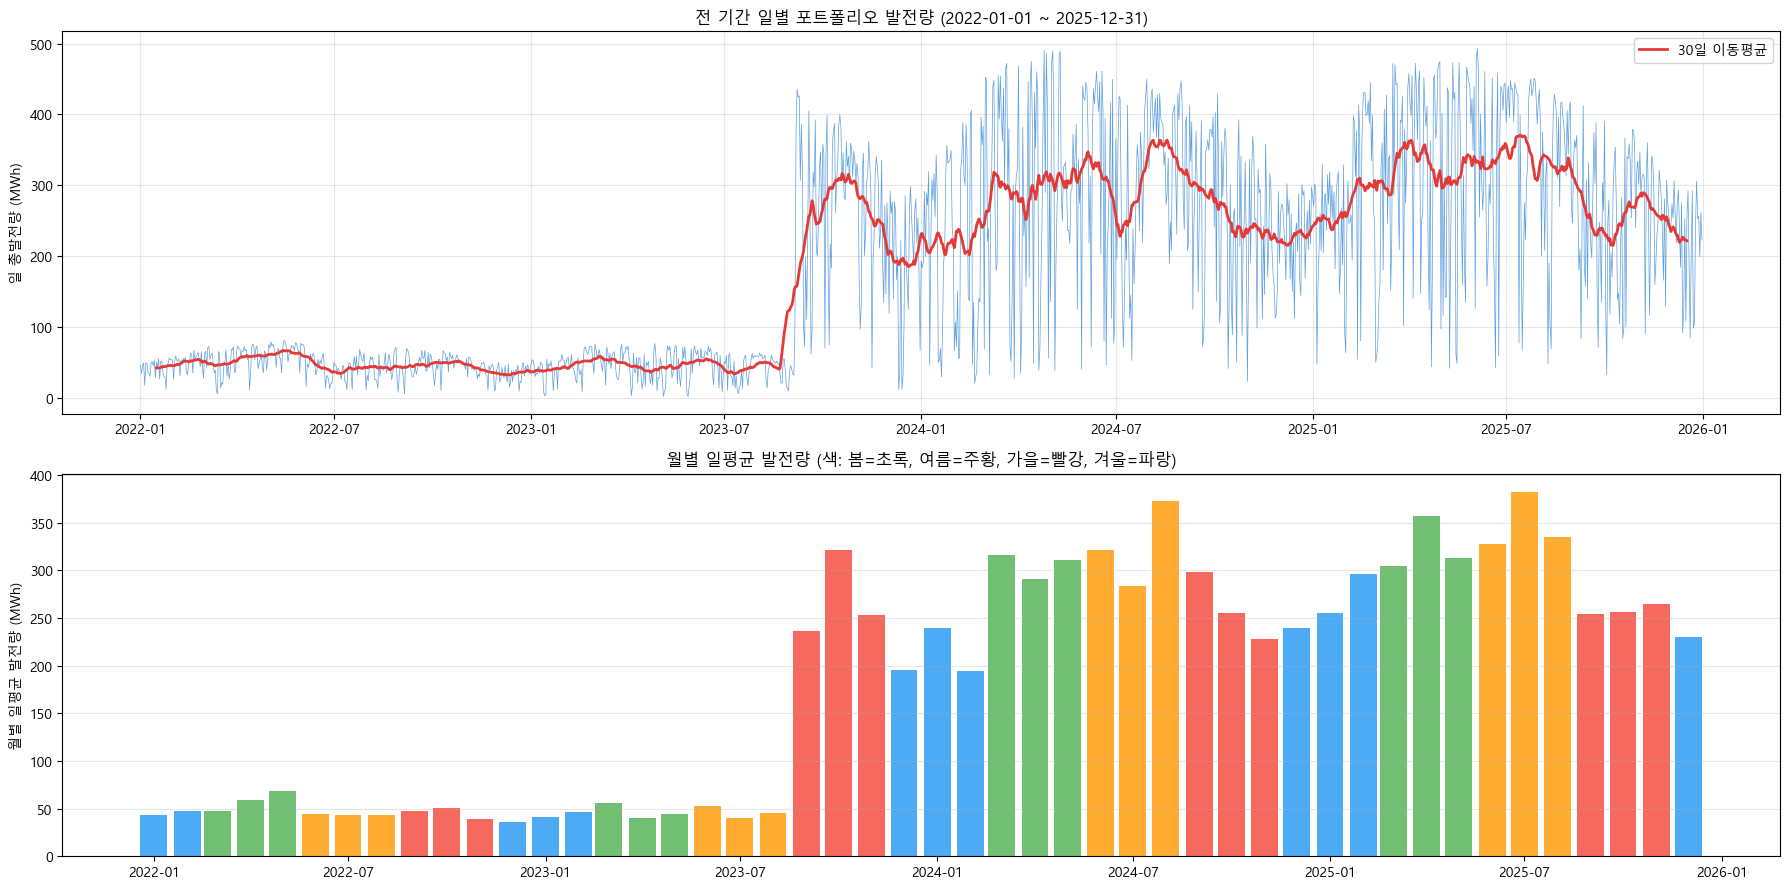

전체 기간 평균 일발전량: 182 MWh
최대일: 2025-06-04 (493 MWh)
최저일: 2023-05-28 (2 MWh)


In [41]:
# 전체 기간 일별 + 월별 패턴
import matplotlib.dates as mdates

portfolio_daily = df.groupby('date')['gen_kwh'].sum() / 1000  # MWh
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
monthly = df.groupby(['year','month'])['gen_kwh'].sum().reset_index()
monthly['ym'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly['daily_avg_mwh'] = monthly['gen_kwh'] / 1000 / 30  # 월 내 일평균

fig, axes = plt.subplots(2, 1, figsize=(18, 9))

# (상) 전체 기간 일별 총발전량
ax = axes[0]
ax.plot(portfolio_daily.index, portfolio_daily.values, color='#1976D2', linewidth=0.5, alpha=0.7)
# 30일 이동평균
rolling = portfolio_daily.rolling(30, center=True).mean()
ax.plot(rolling.index, rolling.values, color='#E53935', linewidth=2, label='30일 이동평균')
ax.set_ylabel('일 총발전량 (MWh)')
ax.set_title(f'전 기간 일별 포트폴리오 발전량 ({df["date"].min().date()} ~ {df["date"].max().date()})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# (하) 월별 바차트
ax = axes[1]
colors = ['#4CAF50' if m in [3,4,5] else '#FF9800' if m in [6,7,8] else '#F44336' if m in [9,10,11] else '#2196F3' for m in monthly['month']]
ax.bar(monthly['ym'], monthly['daily_avg_mwh'], color=colors, alpha=0.8, width=25)
ax.set_ylabel('월별 일평균 발전량 (MWh)')
ax.set_title('월별 일평균 발전량 (색: 봄=초록, 여름=주황, 가을=빨강, 겨울=파랑)')
ax.grid(True, alpha=0.3, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

print(f'전체 기간 평균 일발전량: {portfolio_daily.mean():.0f} MWh')
print(f'최대일: {portfolio_daily.idxmax().date()} ({portfolio_daily.max():.0f} MWh)')
print(f'최저일: {portfolio_daily.idxmin().date()} ({portfolio_daily.min():.0f} MWh)')

## 3. 고흥만 제외 포트폴리오 패턴

고흥만 수상태양광(63.5MW)이 포트폴리오의 81%를 차지하여 §2 시계열은 사실상 "고흥만 그래프". 나머지 10 호기(총 ~14.8 MW)의 자체 패턴을 보기 위해 **고흥만 제외** 시계열을 별도 시각화.

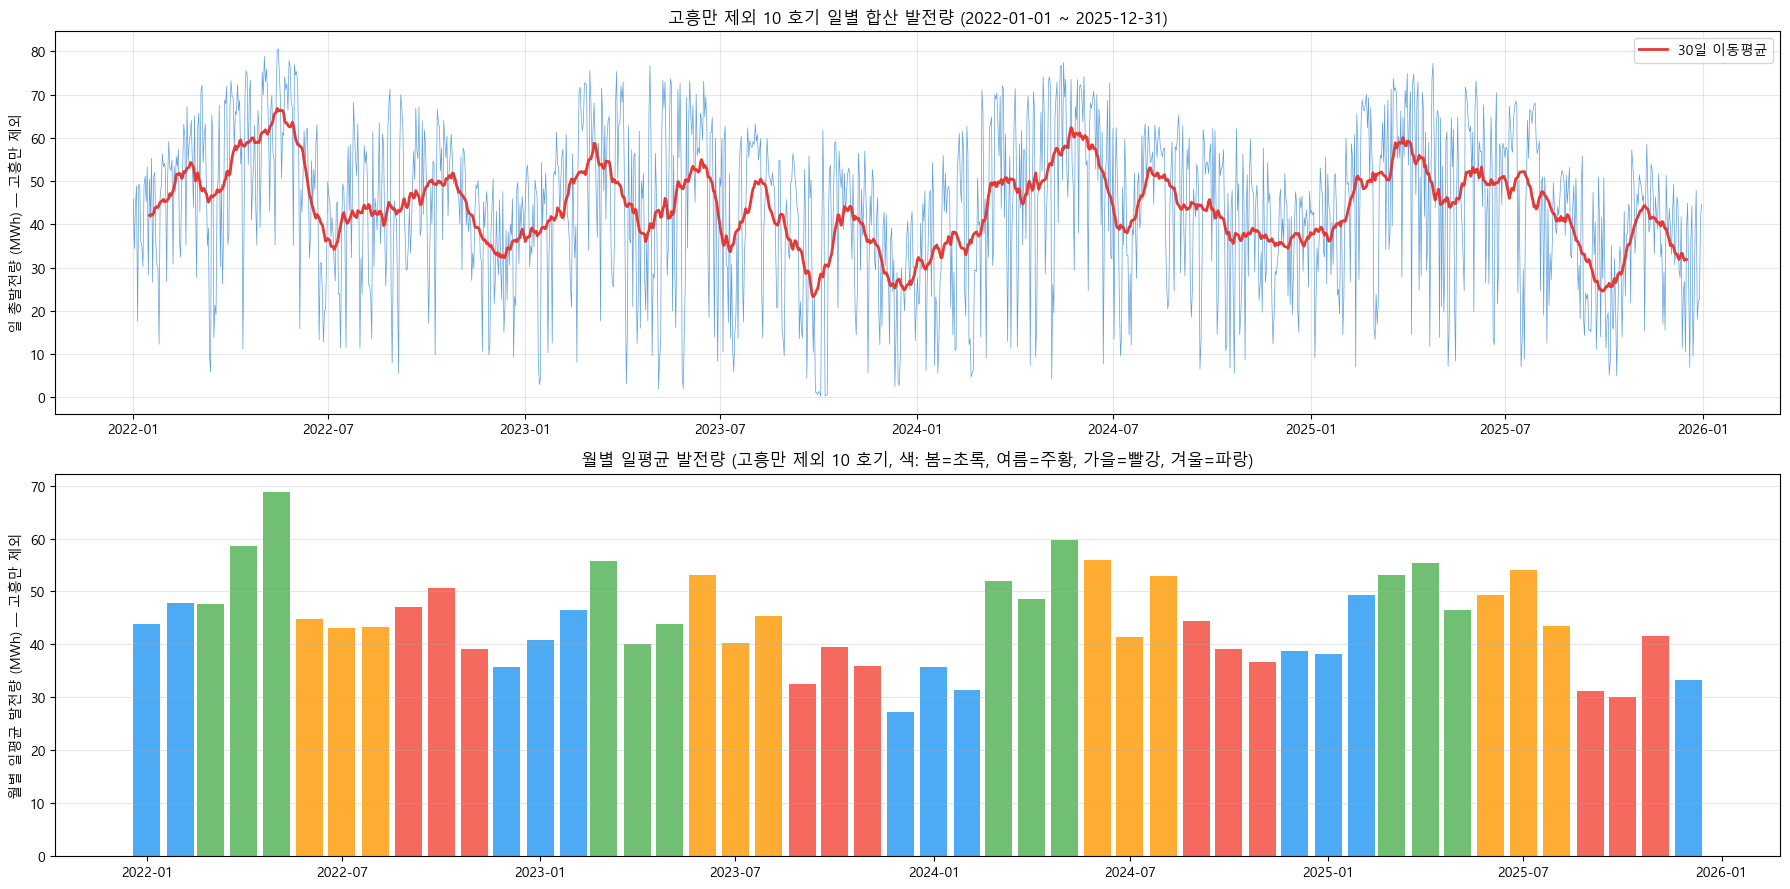

고흥만 제외 평균 일발전량: 43.8 MWh (포트폴리오 전체 대비 ~20%)
최대일: 2022-05-16 (80.6 MWh)
최저일: 2023-10-03 (0.2 MWh)


In [42]:
# 고흥만 제외 포트폴리오
df_no_gh = df[df['site_unit'] != '고흥만 수상태양광#1'].copy()

daily_no_gh = df_no_gh.groupby('date')['gen_kwh'].sum() / 1000  # MWh
df_no_gh['year'] = df_no_gh['date'].dt.year
df_no_gh['month'] = df_no_gh['date'].dt.month
monthly_no_gh = df_no_gh.groupby(['year','month'])['gen_kwh'].sum().reset_index()
monthly_no_gh['ym'] = pd.to_datetime(monthly_no_gh[['year','month']].assign(day=1))
monthly_no_gh['daily_avg_mwh'] = monthly_no_gh['gen_kwh'] / 1000 / 30

fig, axes = plt.subplots(2, 1, figsize=(18, 9))

# (상) 일별 고흥만 제외 총발전량
ax = axes[0]
ax.plot(daily_no_gh.index, daily_no_gh.values, color='#1976D2', linewidth=0.5, alpha=0.7)
rolling = daily_no_gh.rolling(30, center=True).mean()
ax.plot(rolling.index, rolling.values, color='#E53935', linewidth=2, label='30일 이동평균')
ax.set_ylabel('일 총발전량 (MWh) — 고흥만 제외')
ax.set_title(f'고흥만 제외 10 호기 일별 합산 발전량 ({df["date"].min().date()} ~ {df["date"].max().date()})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# (하) 월별 바차트
ax = axes[1]
colors = ['#4CAF50' if m in [3,4,5] else '#FF9800' if m in [6,7,8]
          else '#F44336' if m in [9,10,11] else '#2196F3' for m in monthly_no_gh['month']]
ax.bar(monthly_no_gh['ym'], monthly_no_gh['daily_avg_mwh'], color=colors, alpha=0.8, width=25)
ax.set_ylabel('월별 일평균 발전량 (MWh) — 고흥만 제외')
ax.set_title('월별 일평균 발전량 (고흥만 제외 10 호기, 색: 봄=초록, 여름=주황, 가을=빨강, 겨울=파랑)')
ax.grid(True, alpha=0.3, axis='y')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

print(f'고흥만 제외 평균 일발전량: {daily_no_gh.mean():.1f} MWh (포트폴리오 전체 대비 ~20%)')
print(f'최대일: {daily_no_gh.idxmax().date()} ({daily_no_gh.max():.1f} MWh)')
print(f'최저일: {daily_no_gh.idxmin().date()} ({daily_no_gh.min():.1f} MWh)')

## 4. 연도별 패턴 안정성 — 공통 계절성이 존재·재현되는가

### 왜 포트폴리오 총량 overlay는 틀렸나
- 호기마다 실제 **가동 시점**이 다름 (공식 문서 아닌 **실데이터**로 판정)
- 2022 → 2025 중에 새 호기 추가되어 "가동 중인 포트폴리오"가 연도별로 다름
- 연도별 총량을 비교하면 실제로는 **다른 포트폴리오를 비교**하는 셈 → non-stationary처럼 보이지만 **비교 단위 오류**

### 올바른 단계

**(A) 먼저: GHI NaN × gen 진단**
- GHI 없는 시간(일출·일몰 전후 등)의 gen이 얼마나 되는지 먼저 체크
- 만약 작으면 해당 시간 제외해도 정보 손실 없음 (분석 용이)
- 사용자 요청: "먼저 체크부터, 그 다음 판단"

**(B) 실데이터 기반 가동 일수**
- 각 호기가 실제로 발전한 날 수 (공식 준공일 무시)
- 연도별 가동률 < 70%면 "부분 가동 연도"로 표시

**(C) 호기별 CF 월 overlay** — 같은 호기 내에서 연도 간 겹치는가 (per-unit stationarity)

**(D) 포트폴리오 CF overlay** — 가동 중 호기 용량 합으로 정규화
- `CF_t = Σ gen_i,t / (Σ capacity_i (가동 중) × 시간)`
- 용량 효과 제거 → 호기 변동과 무관한 **순수 계절·기상 패턴만** 남음

→ (C)와 (D) 모두 overlay가 겹친다 = 공통 계절 패턴 stationary = 1층 베이지안 Fourier 항 정당

### 주의
- **호기별 이질성 검증** (FiLM conditioning 필요성)은 **공통성 제거 후** 다음 단계에서. 지금은 공통성 존재 여부만 확인.

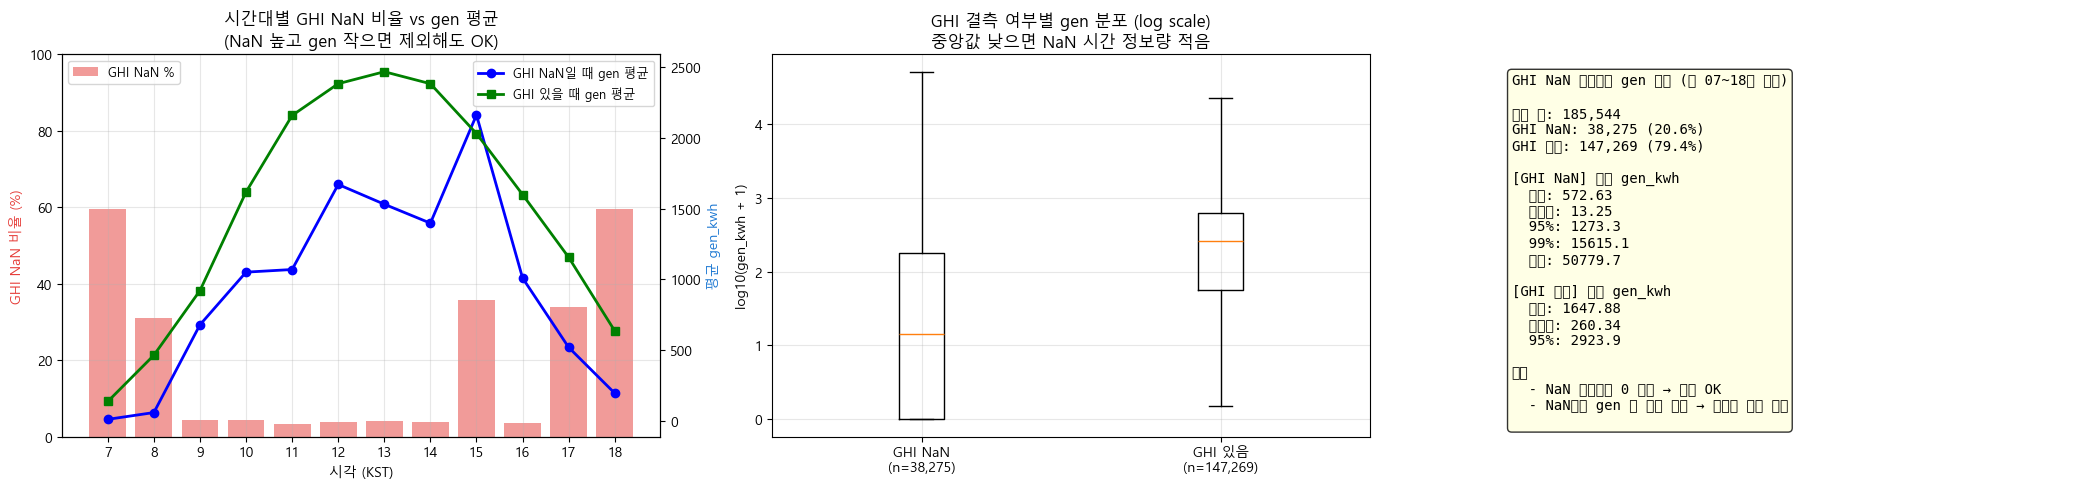

=== GHI NaN인데 gen_kwh > 100 사례 (샘플 10) ===
  총 12,279건 (6.62% of 낮시간)
  site_unit            datetime  hour   gen_kwh
고흥만 수상태양광#1 2024-04-01 12:00:00    12 50779.680
고흥만 수상태양광#1 2025-06-23 12:00:00    12 50063.496
고흥만 수상태양광#1 2024-02-28 14:00:00    14 49509.264
고흥만 수상태양광#1 2024-02-28 13:00:00    13 49314.048
고흥만 수상태양광#1 2024-08-12 13:00:00    13 48850.788
고흥만 수상태양광#1 2024-03-02 15:00:00    15 48687.660
고흥만 수상태양광#1 2024-08-30 12:00:00    12 48098.568
고흥만 수상태양광#1 2025-08-14 14:00:00    14 47435.220
고흥만 수상태양광#1 2025-07-28 14:00:00    14 46714.164
고흥만 수상태양광#1 2025-08-21 13:00:00    13 46510.548
  → GHI 수집 실패인데 실제 발전 있었던 시간


In [43]:
import glob
from calendar import monthrange, isleap

# ===== (A) GHI NaN × gen 분포 진단 =====
# 목적: GHI 없는 시간의 gen이 작으면 해당 시간 제외 가능

SITE_GK2A = {
    '고흥만 수상태양광':'고흥만수상', '삼천포태양광':'삼천포', '영흥태양광':'영흥',
    '영흥태양광#5':'영흥', '광양항세방태양광':'광양항세방', '예천태양광':'예천',
    '구미태양광':'구미', '경상대태양광':'경상대', '두산엔진MG태양광':'창원',
}

ghi_files = sorted(glob.glob('../../data/gk2a_ghi/gk2a_ghi_*.csv'))
ghi_wide = pd.concat([pd.read_csv(f) for f in ghi_files], ignore_index=True)
ghi_wide['datetime_kst'] = pd.to_datetime(ghi_wide['datetime_kst'])
gk2a_cols = [c for c in ghi_wide.columns if c != 'datetime_kst']
ghi_long = ghi_wide.melt(id_vars=['datetime_kst'], value_vars=gk2a_cols,
                          var_name='gk2a_site', value_name='ghi')

df['gk2a_site'] = df['site'].map(SITE_GK2A)
pv_ghi = df.merge(ghi_long, left_on=['datetime','gk2a_site'],
                   right_on=['datetime_kst','gk2a_site'], how='left')
pv_ghi['hour'] = pv_ghi['datetime'].dt.hour

# 낮 시간대(GHI 수집 범위 07~18)만
pv_day = pv_ghi[(pv_ghi['hour'] >= 7) & (pv_ghi['hour'] <= 18)].copy()

# 시간대별 요약
hr_summary = pv_day.groupby('hour').agg(
    n=('gen_kwh', 'size'),
    ghi_nan_pct=('ghi', lambda s: 100 * s.isna().mean()),
    gen_when_ghi_nan=('gen_kwh', lambda s: s[pv_day.loc[s.index, 'ghi'].isna()].mean() if pv_day.loc[s.index, 'ghi'].isna().any() else np.nan),
    gen_when_ghi_ok=('gen_kwh',  lambda s: s[pv_day.loc[s.index, 'ghi'].notna()].mean() if pv_day.loc[s.index, 'ghi'].notna().any() else np.nan),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# (1) 시간대별 GHI NaN% vs gen 평균 (GHI 유무 비교)
ax = axes[0]
ax.bar(hr_summary['hour'], hr_summary['ghi_nan_pct'], color='#E53935', alpha=0.5, label='GHI NaN %')
ax.set_xlabel('시각 (KST)')
ax.set_ylabel('GHI NaN 비율 (%)', color='#E53935')
ax.set_ylim(0, 100)
ax2 = ax.twinx()
ax2.plot(hr_summary['hour'], hr_summary['gen_when_ghi_nan'], 'b-o', label='GHI NaN일 때 gen 평균', linewidth=2)
ax2.plot(hr_summary['hour'], hr_summary['gen_when_ghi_ok'],  'g-s', label='GHI 있을 때 gen 평균', linewidth=2)
ax2.set_ylabel('평균 gen_kwh', color='#1976D2')
ax.set_xticks(range(7, 19))
ax.set_title('시간대별 GHI NaN 비율 vs gen 평균\n(NaN 높고 gen 작으면 제외해도 OK)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

# (2) GHI 있음 vs 없음 gen 분포 (log y)
ax = axes[1]
data_nan = pv_day.loc[pv_day['ghi'].isna(), 'gen_kwh'].dropna()
data_ok  = pv_day.loc[pv_day['ghi'].notna(), 'gen_kwh'].dropna()
# gen_kwh가 0이면 log 불가 → 1 더해서 시각화
ax.boxplot([np.log10(data_nan + 1), np.log10(data_ok + 1)],
           labels=[f'GHI NaN\n(n={len(data_nan):,})', f'GHI 있음\n(n={len(data_ok):,})'],
           showfliers=False)
ax.set_ylabel('log10(gen_kwh + 1)')
ax.set_title('GHI 결측 여부별 gen 분포 (log scale)\n중앙값 낮으면 NaN 시간 정보량 적음')
ax.grid(True, alpha=0.3)

# (3) 요약 수치
ax = axes[2]
ax.axis('off')
n_nan = pv_day['ghi'].isna().sum()
n_ok  = pv_day['ghi'].notna().sum()
gen_nan_med = data_nan.median()
gen_ok_med  = data_ok.median()

stats_text = f"""GHI NaN 시간대의 gen 분포 (낮 07~18시 기준)

전체 행: {len(pv_day):,}
GHI NaN: {n_nan:,} ({100*n_nan/len(pv_day):.1f}%)
GHI 있음: {n_ok:,} ({100*n_ok/len(pv_day):.1f}%)

[GHI NaN] 시의 gen_kwh
  평균: {data_nan.mean():.2f}
  중앙값: {gen_nan_med:.2f}
  95%: {data_nan.quantile(0.95):.1f}
  99%: {data_nan.quantile(0.99):.1f}
  최대: {data_nan.max():.1f}

[GHI 있음] 시의 gen_kwh
  평균: {data_ok.mean():.2f}
  중앙값: {gen_ok_med:.2f}
  95%: {data_ok.quantile(0.95):.1f}

판정
  - NaN 중앙값이 0 근처 → 제외 OK
  - NaN에도 gen 큰 경우 있음 → 호기별 진단 필요
"""
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=10, family='monospace', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# GHI NaN이지만 gen 유의미한 예 (고장·매칭 오류 탐지)
print('=== GHI NaN인데 gen_kwh > 100 사례 (샘플 10) ===')
high = pv_day[pv_day['ghi'].isna() & (pv_day['gen_kwh'] > 100)]
if len(high) > 0:
    print(f'  총 {len(high):,}건 ({100*len(high)/len(pv_day):.2f}% of 낮시간)')
    print(high.nlargest(10, 'gen_kwh')[['site_unit','datetime','hour','gen_kwh']].to_string(index=False))
    print('  → GHI 수집 실패인데 실제 발전 있었던 시간')
else:
    print('  없음. NaN은 정말 저각도/gen≈0 구간.')

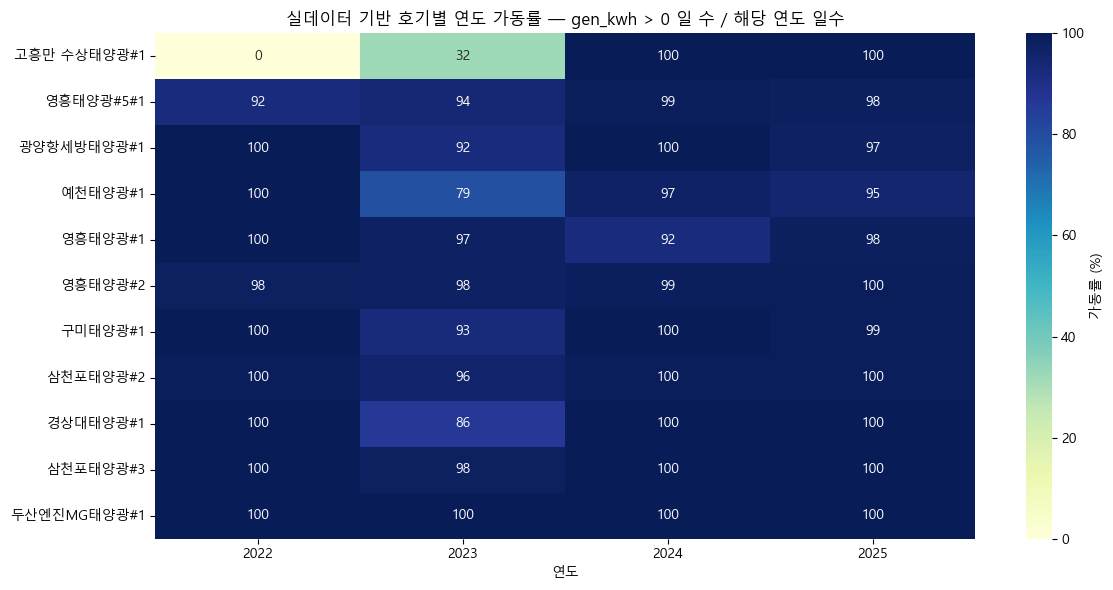

해석
  100%: 연중 매일 발전 (완전 가동)
  70~99%: 일부 결측 or 단기 중단 (포함 권장)
  < 70%: 준공 초기 or 장기 중단 (CF 계산 시 유의)
  0%: 해당 연도 가동 없음 (계절성 비교 불가)


In [47]:
import seaborn as sns
from calendar import isleap

# ===== (B) 실데이터 기반 호기별 연도 가동률 =====
# 공식 문서 무시. gen_kwh > 0 인 날을 실제 가동일로 간주.

def year_days(y): return 366 if isleap(y) else 365

years = sorted(df['year'].unique())
unit_order = sorted(UNIT_CAPACITY_KW.keys(), key=lambda u: -UNIT_CAPACITY_KW[u])

# 호기 × 연도: 발전 있는 날 수
active_days = {}
for u in unit_order:
    for y in years:
        g = df[(df['site_unit']==u) & (df['year']==y)]
        n_active = (g.groupby('date')['gen_kwh'].sum() > 0).sum()
        active_days[(u, y)] = n_active

active_df = pd.DataFrame(
    {y: [active_days.get((u, y), 0) for u in unit_order] for y in years},
    index=unit_order
)
active_pct = active_df.copy()
for y in years:
    active_pct[y] = (active_df[y] / year_days(y) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(active_pct, annot=True, fmt='.0f', cmap='YlGnBu',
            vmin=0, vmax=100, ax=ax, cbar_kws={'label':'가동률 (%)'})
ax.set_title('실데이터 기반 호기별 연도 가동률 — gen_kwh > 0 일 수 / 해당 연도 일수')
ax.set_xlabel('연도')
plt.tight_layout()
plt.show()

print('해석')
print('  100%: 연중 매일 발전 (완전 가동)')
print('  70~99%: 일부 결측 or 단기 중단 (포함 권장)')
print('  < 70%: 준공 초기 or 장기 중단 (CF 계산 시 유의)')
print('  0%: 해당 연도 가동 없음 (계절성 비교 불가)')

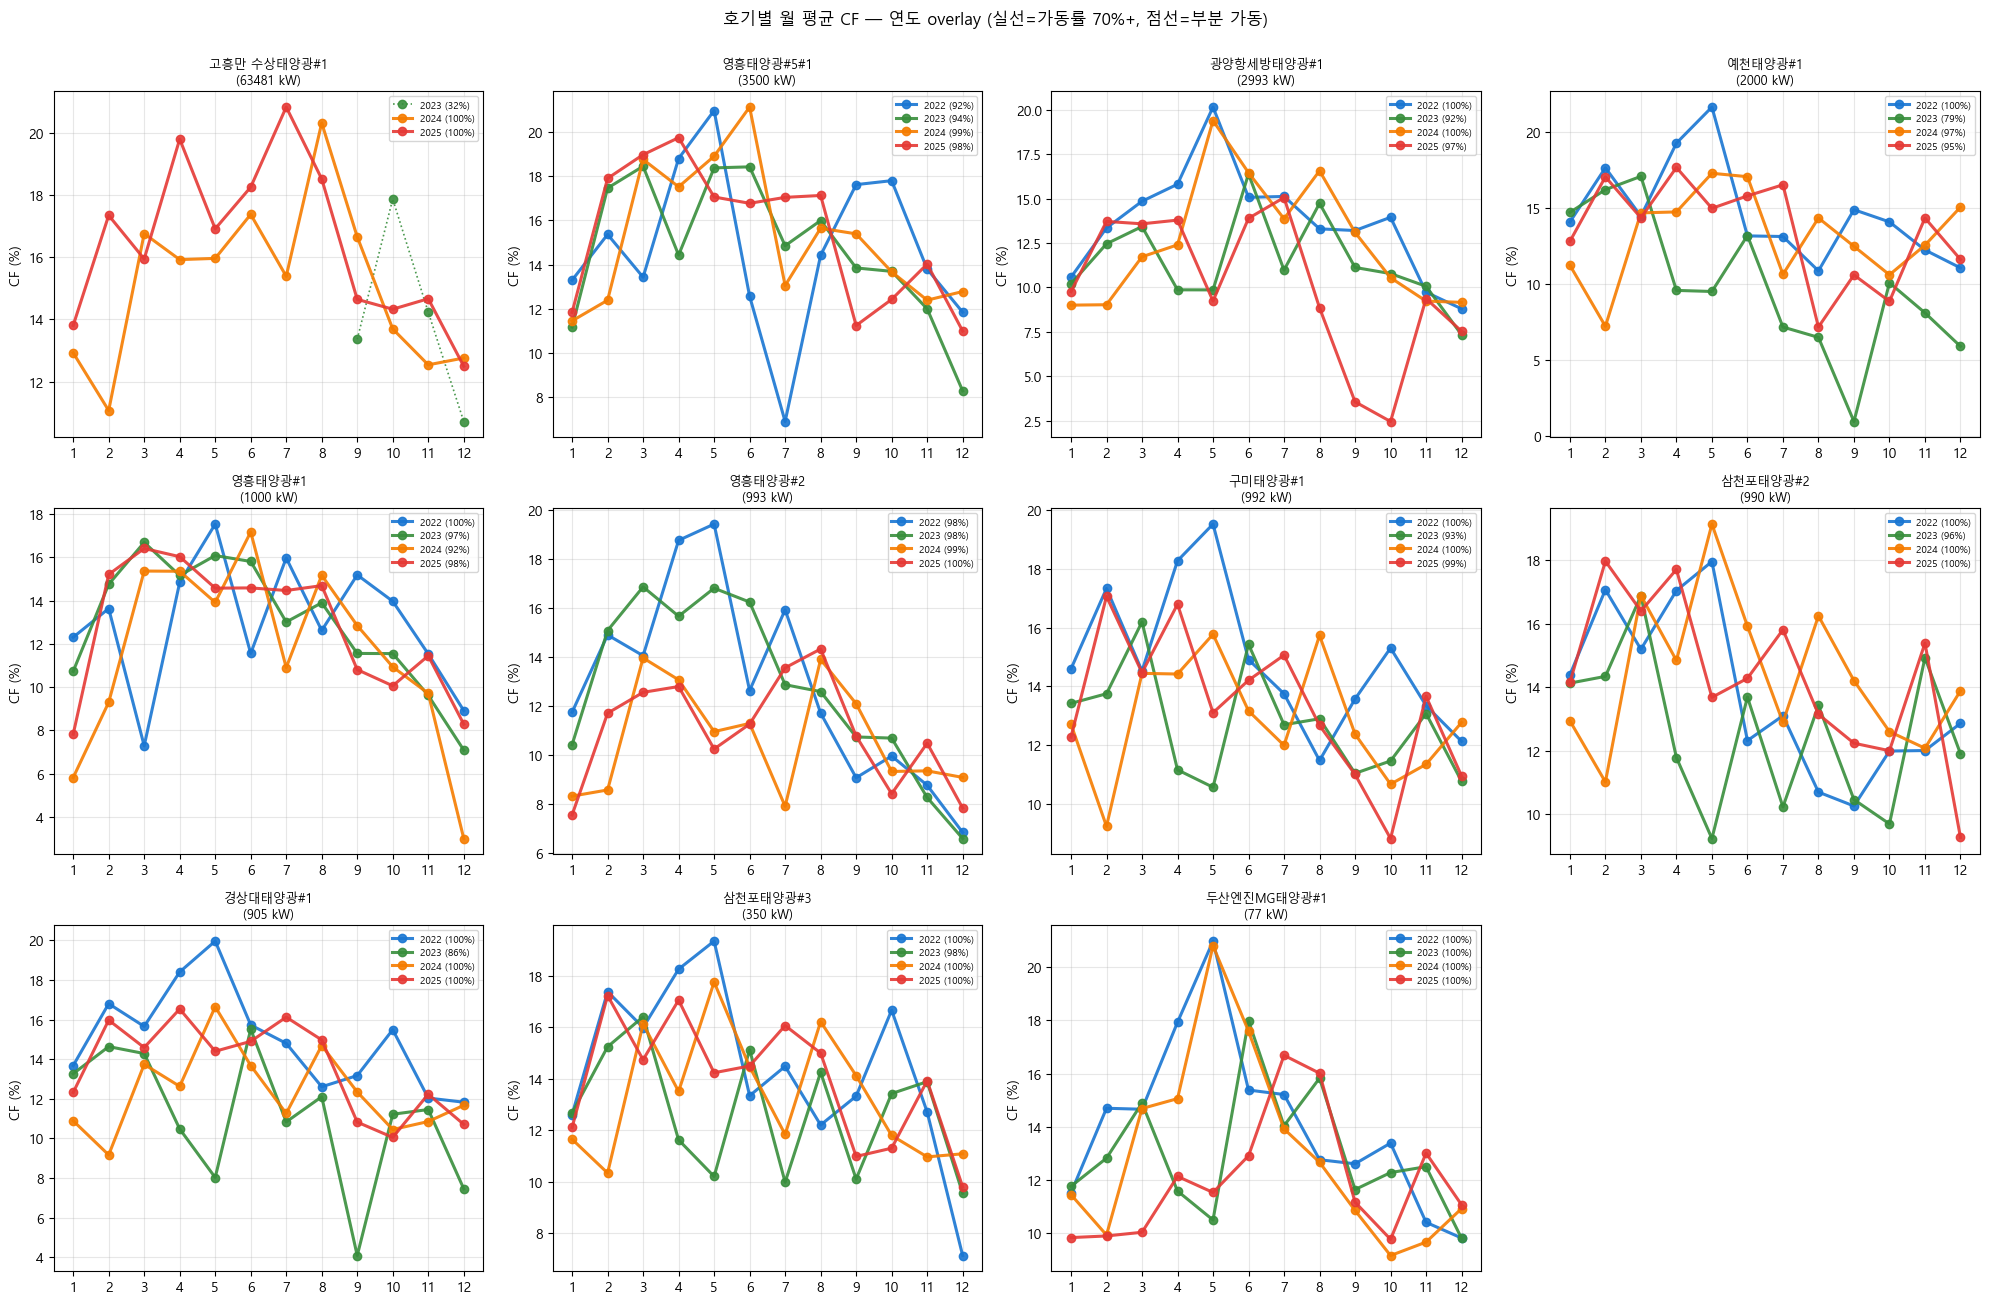

판독 기준
  - 실선(완전 가동 연도)들끼리 overlay가 겹침 → per-unit stationary
  - 점선은 부분 가동 연도라 참고용
  - 피크 월(5월 or 8월)이 매년 동일 → 계절 재현


In [45]:
# ===== (C) 호기별 CF 월 overlay — 연도 간 재현성 =====
# CF = gen_kwh / 호기 용량 (kW). 호기 크기 정규화 → 형태 비교 가능.

df['cf'] = df.apply(lambda r: r['gen_kwh'] / UNIT_CAPACITY_KW.get(r['site_unit'], np.nan), axis=1)
cf_monthly = df.groupby(['site_unit','year','month'])['cf'].mean().reset_index()

colors_year = {2022:'#1976D2', 2023:'#388E3C', 2024:'#F57C00', 2025:'#E53935'}

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for i, u in enumerate(unit_order):
    ax = axes[i]
    sub = cf_monthly[cf_monthly['site_unit']==u]
    for y in years:
        ys = sub[sub['year']==y].sort_values('month')
        if len(ys) == 0:
            continue
        pct = active_pct.loc[u, y]
        ls = '-' if pct > 70 else ':'
        lw = 2.2 if pct > 70 else 1.2
        ax.plot(ys['month'], ys['cf']*100, linestyle=ls, marker='o', linewidth=lw,
                label=f'{y} ({pct:.0f}%)',
                color=colors_year.get(y, 'gray'), alpha=0.9)
    ax.set_xticks(range(1, 13))
    ax.set_title(f'{u}\n({UNIT_CAPACITY_KW.get(u)} kW)', fontsize=9)
    ax.set_ylabel('CF (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

for j in range(len(unit_order), len(axes)):
    axes[j].axis('off')

plt.suptitle('호기별 월 평균 CF — 연도 overlay (실선=가동률 70%+, 점선=부분 가동)',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

print('판독 기준')
print('  - 실선(완전 가동 연도)들끼리 overlay가 겹침 → per-unit stationary')
print('  - 점선은 부분 가동 연도라 참고용')
print('  - 피크 월(5월 or 8월)이 매년 동일 → 계절 재현')

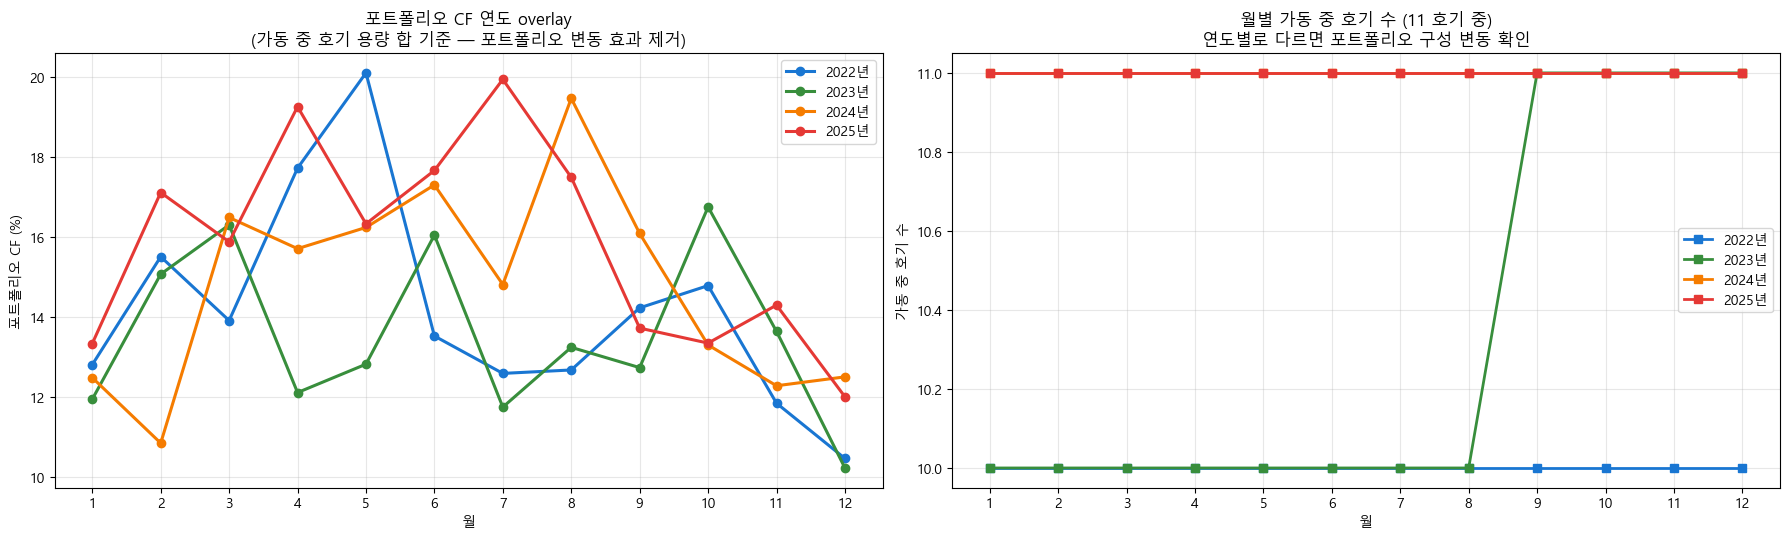

=== 포트폴리오 CF 연도 요약 ===
  2022: 평균 CF 14.2%, 피크 CF 20.1% (5월)
  2023: 평균 CF 13.5%, 피크 CF 16.7% (10월)
  2024: 평균 CF 14.8%, 피크 CF 19.5% (8월)
  2025: 평균 CF 15.9%, 피크 CF 19.9% (7월)

판독 기준
  - 연도 overlay 겹침 → 공통 계절 패턴 stationary (1층 Fourier 정당)
  - 피크 월 매년 동일 → 재현성
  - 특정 연도만 이탈 → 기상 이벤트 or 데이터 문제


In [46]:
# ===== (D) 포트폴리오 CF overlay — 가동 중 호기 용량 합 기준 =====
# 각 (호기, 월)이 "가동 중"인지 gen > 0 기준으로 판정.
# CF_portfolio = Σ gen / (Σ active_capacity × 월 시간수)

pv_mu = df.groupby(['site_unit','year','month'])['gen_kwh'].sum().reset_index()
pv_mu['cap'] = pv_mu['site_unit'].map(UNIT_CAPACITY_KW)
pv_mu['active'] = pv_mu['gen_kwh'] > 0
pv_mu['active_cap'] = pv_mu['cap'] * pv_mu['active']

agg = pv_mu.groupby(['year','month']).agg(
    gen_sum=('gen_kwh','sum'),
    active_cap_sum=('active_cap','sum'),
    active_units=('active', 'sum'),
).reset_index()
agg['hours'] = agg.apply(lambda r: monthrange(int(r['year']), int(r['month']))[1] * 24, axis=1)
# CF = gen(kWh) / (active_capacity(kW) × hours) × 100 %
agg['cf_pct'] = np.where(agg['active_cap_sum'] > 0,
                          agg['gen_sum'] / (agg['active_cap_sum'] * agg['hours']) * 100,
                          np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

# (좌) 포트폴리오 CF overlay
ax = axes[0]
for y in years:
    sub = agg[agg['year']==y].sort_values('month')
    if len(sub) == 0: continue
    ax.plot(sub['month'], sub['cf_pct'], marker='o', linewidth=2.2,
            label=f'{y}년', color=colors_year.get(y, 'gray'))
ax.set_xticks(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('포트폴리오 CF (%)')
ax.set_title('포트폴리오 CF 연도 overlay\n(가동 중 호기 용량 합 기준 — 포트폴리오 변동 효과 제거)')
ax.legend()
ax.grid(True, alpha=0.3)

# (우) 월별 가동 호기 수 (변동 시각화 — 1층에서 random intercept 필요성 근거)
ax = axes[1]
for y in years:
    sub = agg[agg['year']==y].sort_values('month')
    if len(sub) == 0: continue
    ax.plot(sub['month'], sub['active_units'], marker='s', linewidth=2,
            label=f'{y}년', color=colors_year.get(y, 'gray'))
ax.set_xticks(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('가동 중 호기 수')
ax.set_title('월별 가동 중 호기 수 (11 호기 중)\n연도별로 다르면 포트폴리오 구성 변동 확인')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('=== 포트폴리오 CF 연도 요약 ===')
for y in years:
    sub = agg[agg['year']==y]
    if len(sub) == 0: continue
    cf_mean = sub['cf_pct'].mean()
    cf_peak = sub['cf_pct'].max()
    peak_mo = int(sub.loc[sub['cf_pct'].idxmax(), 'month']) if not sub['cf_pct'].isna().all() else -1
    print(f'  {y}: 평균 CF {cf_mean:.1f}%, 피크 CF {cf_peak:.1f}% ({peak_mo}월)')

print('\n판독 기준')
print('  - 연도 overlay 겹침 → 공통 계절 패턴 stationary (1층 Fourier 정당)')
print('  - 피크 월 매년 동일 → 재현성')
print('  - 특정 연도만 이탈 → 기상 이벤트 or 데이터 문제')

## 5. ASOS 일사량 vs GK-2A GHI 비교 (참고)

학습용 GHI를 **ASOS `icsr`** (관측소 거리 5~30km, MJ/m² 시간적산)에서 **GK-2A 위성 DSR** (사이트 바로 위 2km 격자, W/m² 시간평균)로 전환한 것이 실제로 얼마나 일관된지 확인.

단위 환산: ASOS `icsr × 277.78` → W/m² 근사 (시간적산↔평균 변환).

**선험 기대**:
- `r > 0.95`: 두 소스가 매우 일관 (GK-2A로 안전하게 대체 가능)
- 남해·구미 ASOS는 `icsr` 미관측이라 비교 불가 → **GK-2A가 유일한 해결책**

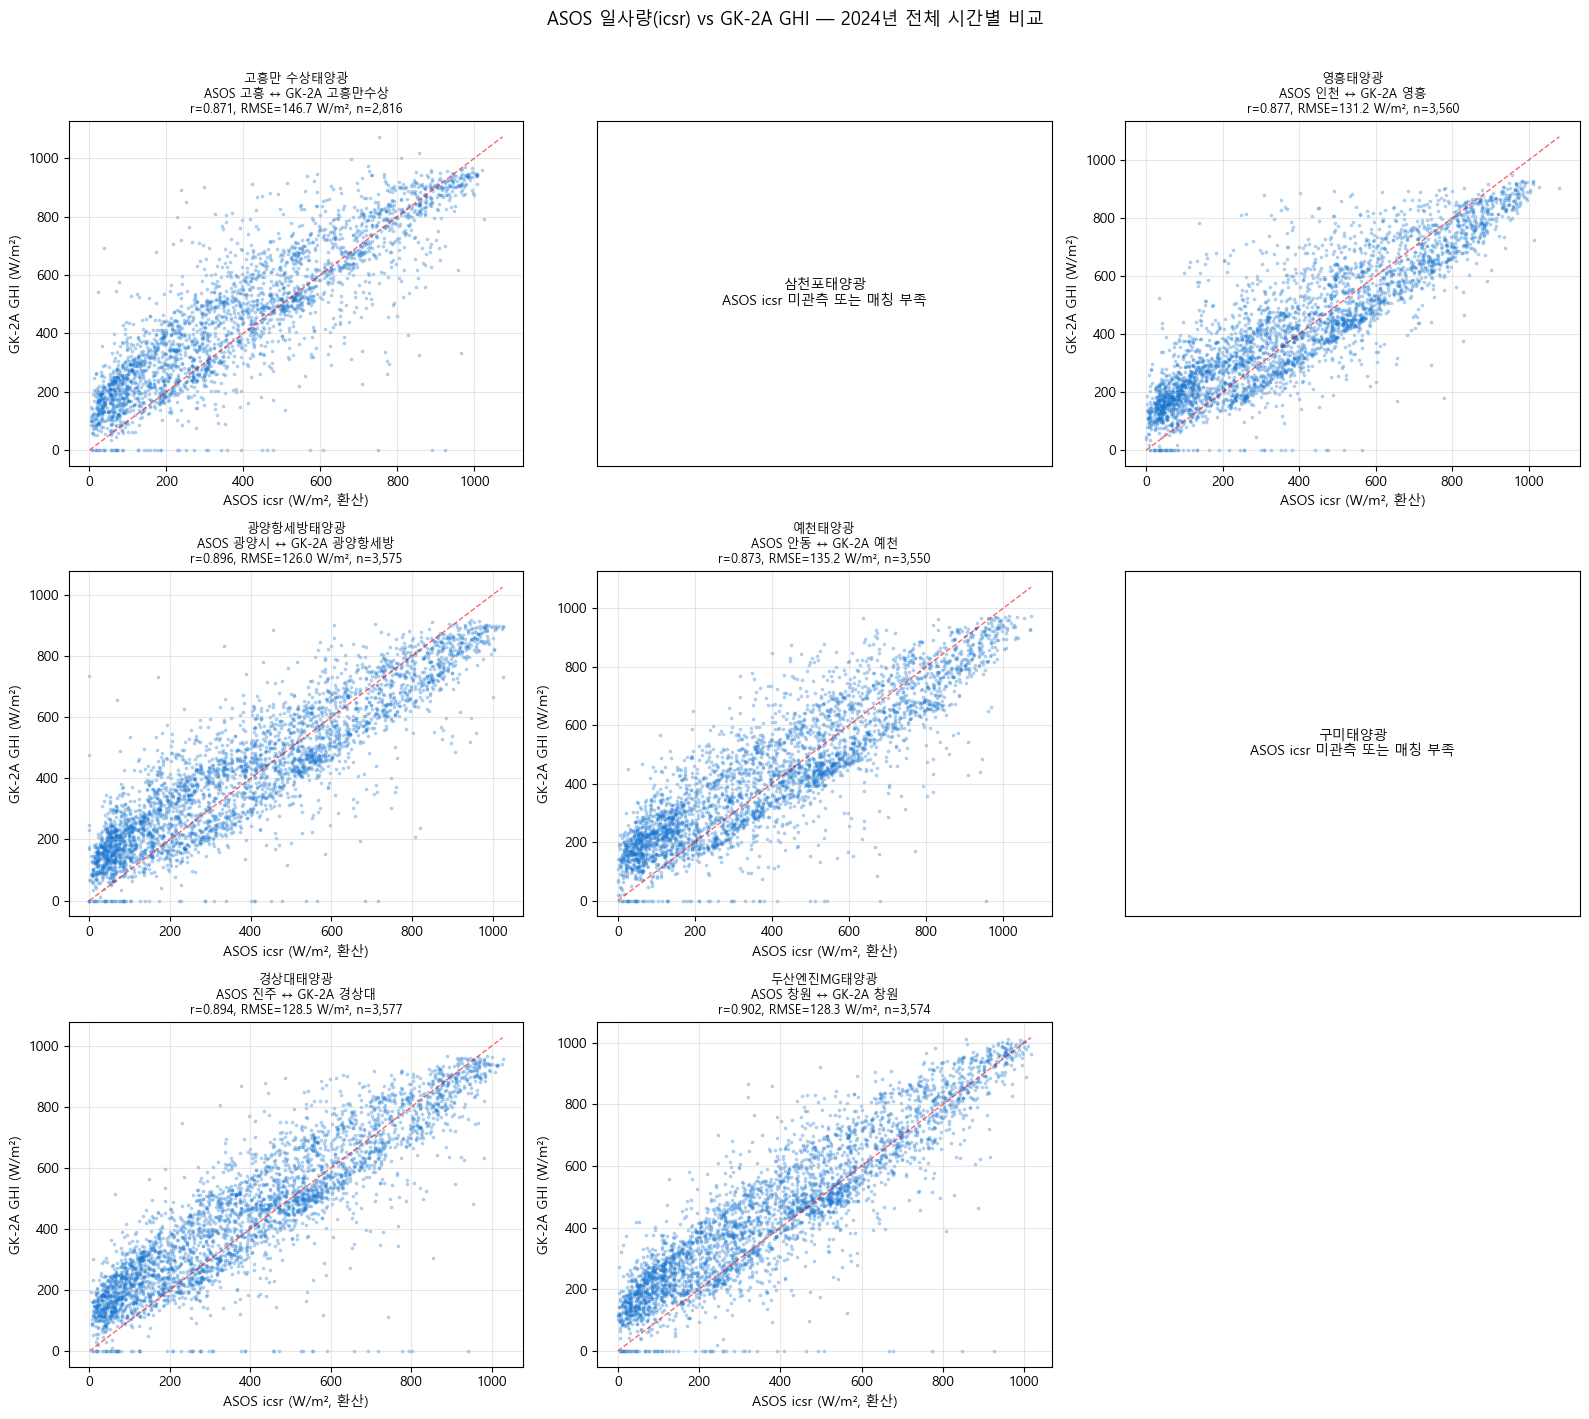

해석
  - r > 0.95: 두 소스가 매우 일관 → GK-2A 학습 데이터로 신뢰 가능
  - r < 0.9:  관측 환경 차이 (ASOS 관측소가 먼 경우)
  - RMSE: 절대 편차 크기 — GK-2A W/m² 순시 vs ASOS 시간적산의 구조적 차이 포함
  - 남해·구미는 ASOS icsr 미관측 → 매칭 불가 (삼천포·구미 사이트는 GK-2A 독점 필수)


In [ ]:
import glob, os

# ===== ASOS icsr vs GK-2A GHI — 같은 시각·같은 사이트 동시 비교 =====
# ASOS icsr: MJ/m² (시간적산)  → W/m² 환산: × 1000000 / 3600 ≈ × 277.78
# GK-2A DSR: W/m² (시간 평균)

# 사이트 → ASOS 매핑
SITE_TO_STN = {
    '고흥만 수상태양광':'고흥', '삼천포태양광':'남해', '영흥태양광':'인천',
    '영흥태양광#5':'인천', '광양항세방태양광':'광양시', '예천태양광':'안동',
    '구미태양광':'구미', '경상대태양광':'진주', '두산엔진MG태양광':'창원',
}
# 사이트 → GK-2A 컬럼
SITE_TO_GK2A = {
    '고흥만 수상태양광':'고흥만수상', '삼천포태양광':'삼천포', '영흥태양광':'영흥',
    '영흥태양광#5':'영흥', '광양항세방태양광':'광양항세방', '예천태양광':'예천',
    '구미태양광':'구미', '경상대태양광':'경상대', '두산엔진MG태양광':'창원',
}

# 2024년 전체 (가장 품질 안정)
asos_files = sorted(glob.glob('../../data/asos_hourly/asos_hourly_2024*.csv'))
asos_all = pd.concat([pd.read_csv(f) for f in asos_files], ignore_index=True)
asos_all['tm'] = pd.to_datetime(asos_all['tm'])
asos_all['icsr_wm2'] = asos_all['icsr'] * (1_000_000 / 3600)  # MJ/m²h → W/m²

ghi_files = sorted(glob.glob('../../data/gk2a_ghi/gk2a_ghi_2024*.csv'))
ghi_all = pd.concat([pd.read_csv(f) for f in ghi_files], ignore_index=True)
ghi_all['datetime_kst'] = pd.to_datetime(ghi_all['datetime_kst'])

# 사이트별 ASOS/GK-2A 페어 생성
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

common_sites = [
    ('고흥만 수상태양광','고흥','고흥만수상'),
    ('삼천포태양광','남해','삼천포'),
    ('영흥태양광','인천','영흥'),
    ('광양항세방태양광','광양시','광양항세방'),
    ('예천태양광','안동','예천'),
    ('구미태양광','구미','구미'),
    ('경상대태양광','진주','경상대'),
    ('두산엔진MG태양광','창원','창원'),
]

for i, (site_name, stn, gk2a_col) in enumerate(common_sites):
    ax = axes[i]
    a = asos_all[asos_all['stnNm'] == stn][['tm','icsr_wm2']].rename(columns={'tm':'t'})
    g = ghi_all[['datetime_kst', gk2a_col]].rename(columns={'datetime_kst':'t', gk2a_col:'ghi_gk2a'})
    m = a.merge(g, on='t', how='inner').dropna(subset=['icsr_wm2','ghi_gk2a'])
    if len(m) < 100:
        ax.text(0.5, 0.5, f'{site_name}\nASOS icsr 미관측 또는 매칭 부족', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    # 산점도
    ax.scatter(m['icsr_wm2'], m['ghi_gk2a'], s=3, alpha=0.25, color='#1976D2')
    # y=x 참조선
    mx = max(m['icsr_wm2'].max(), m['ghi_gk2a'].max())
    ax.plot([0, mx], [0, mx], 'r--', alpha=0.6, linewidth=1)
    r = m['icsr_wm2'].corr(m['ghi_gk2a'])
    rmse = np.sqrt(((m['icsr_wm2'] - m['ghi_gk2a'])**2).mean())
    ax.set_title(f'{site_name}\nASOS {stn} ↔ GK-2A {gk2a_col}\n'
                 f'r={r:.3f}, RMSE={rmse:.1f} W/m², n={len(m):,}', fontsize=9)
    ax.set_xlabel('ASOS icsr (W/m², 환산)')
    ax.set_ylabel('GK-2A GHI (W/m²)')
    ax.grid(True, alpha=0.3)

# 빈 셀 숨김
for j in range(len(common_sites), len(axes)):
    axes[j].axis('off')

plt.suptitle('ASOS 일사량(icsr) vs GK-2A GHI — 2024년 전체 시간별 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('해석')
print('  - r > 0.95: 두 소스가 매우 일관 → GK-2A 학습 데이터로 신뢰 가능')
print('  - r < 0.9:  관측 환경 차이 (ASOS 관측소가 먼 경우)')
print('  - RMSE: 절대 편차 크기 — GK-2A W/m² 순시 vs ASOS 시간적산의 구조적 차이 포함')
print('  - 남해·구미는 ASOS icsr 미관측 → 매칭 불가 (삼천포·구미 사이트는 GK-2A 독점 필수)')